# Machine Learning - Previsão por Categoria Criminal

Este notebook treina e avalia modelos para prever taxas criminais por 100 mil habitantes nas capitais brasileiras.

Fonte oficial:

`datamart.vw_indicadores_municipio_ano`

Estratégia metodológica:

- **Linear Regression**: baseline simples e interpretável.
- **Random Forest Regressor**: modelo principal candidato, capaz de capturar relações não lineares.

O objetivo é comparar o desempenho dos modelos para a taxa geral de crimes e para categorias específicas, como homicídios, estupros, furto/roubo de veículos, feminicídios e mortes violentas intencionais.

## 1. Imports

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sqlalchemy import create_engine

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')

## 2. Conexão com o PostgreSQL

Dentro do Docker Compose, o host do PostgreSQL é `postgres-service`.

Se o notebook for executado fora do container, altere `POSTGRES_HOST` para `localhost`.

In [2]:
DB_USER = os.getenv('POSTGRES_USER', 'postgres')
DB_PASSWORD = os.getenv('POSTGRES_PASSWORD', 'postgres')
DB_HOST = os.getenv('POSTGRES_HOST', 'postgres-service')
DB_PORT = os.getenv('POSTGRES_PORT', '5432')
DB_NAME = os.getenv('POSTGRES_DB', 'seguranca_publica')

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

## 3. Carregar base analítica

Usamos a view executiva do Data Mart porque ela contém as taxas gerais, categorias criminais, dados socioeconômicos, população e educação.

In [3]:
query = """
SELECT *
FROM datamart.vw_indicadores_municipio_ano
ORDER BY codigo_municipio, ano;
"""

df_raw = pd.read_sql(query, engine)
df_raw.head()

,id_fato_municipio_ano_dw,ano,decada,periodo_analise,codigo_municipio,nome_municipio,nome_municipio_padronizado,codigo_uf_ibge,sigla_uf,nome_uf,...,taxa_mortes_violentas_100k,taxa_homicidios_100k,taxa_feminicidios_100k,taxa_estupros_100k,taxa_furto_veiculos_100k,risco_indice,classificacao_risco,ranking_risco_ano,ranking_taxa_crimes_ano,ranking_homicidios_ano
0,1,2016,2010,Periodo de analise,1100205,Porto Velho,porto velho,11,RO,Rondonia,...,38.254091,34.648994,NaN,76.508183,373.928735,0.622802,Risco medio,4,1,15
1,2,2017,2010,Periodo de analise,1100205,Porto Velho,porto velho,11,RO,Rondonia,...,31.021572,29.843537,NaN,69.700367,365.190655,0.544321,Risco medio,9,1,17
2,3,2018,2010,Periodo de analise,1100205,Porto Velho,porto velho,11,RO,Rondonia,...,30.797007,29.257157,0.769925,68.330860,358.015210,0.487566,Risco moderado,6,2,15
3,4,2019,2010,Periodo de analise,1100205,Porto Velho,porto velho,11,RO,Rondonia,...,22.472165,19.828381,0.188842,65.150394,375.983865,0.356798,Risco moderado,7,1,16
4,5,2020,2020,Periodo de analise,1100205,Porto Velho,porto velho,11,RO,Rondonia,...,29.850525,26.142385,0.927035,52.840991,NaN,0.443992,Risco moderado,5,27,12


## 4. Diagnóstico inicial

In [4]:
display(df_raw.shape)
display(df_raw.dtypes)
display(df_raw.isna().sum().sort_values(ascending=False).head(30))
display(df_raw.groupby('ano').size().rename('qtd_linhas'))

(243, 46)

id_fato_municipio_ano_dw           int64
ano                                int64
decada                             int64
periodo_analise                   object
codigo_municipio                   int64
nome_municipio                    object
nome_municipio_padronizado        object
codigo_uf_ibge                     int64
sigla_uf                          object
nome_uf                           object
nome_regiao                       object
ciclo_id                          object
descricao_ciclo                   object
dependencia_id                   float64
descricao_dependencia             object
populacao_total                  float64
populacao_crescimento_pct        float64
idhm                             float64
idhm_renda                       float64
idhm_educacao                    float64
idhm_longevidade                 float64
ano_referencia_idhm                int64
ideb                             float64
fluxo                            float64
aprendizado     

crimes_total_indicadores         141
taxa_crimes_100k                 141
ciclo_id                         136
nota_lp                          136
nota_mt                          136
aprendizado                      136
ideb                             136
dependencia_id                   136
descricao_ciclo                  136
fluxo                            136
descricao_dependencia            136
taxa_furto_veiculos_100k          89
roubo_veiculos                    89
furto_veiculos                    89
taxa_estupros_100k                83
estupros                          83
taxa_feminicidios_100k            56
feminicidios                      56
populacao_crescimento_pct         27
mortes_violentas_intencionais      0
latrocinios                        0
taxa_homicidios_100k               0
risco_indice                       0
homicidios_dolosos                 0
classificacao_risco                0
ranking_risco_ano                  0
ranking_taxa_crimes_ano            0
t

ano
2016    27
2017    27
2018    27
2019    27
2020    27
2021    27
2022    27
2023    27
2024    27
Name: qtd_linhas, dtype: int64

## 5. Preparação da base

Como o IDEB não é divulgado todos os anos, usamos `forward fill` por UF para propagar o último valor educacional conhecido.

Isso não usa informação futura: cada ano recebe apenas o último valor disponível até aquele momento.

In [5]:
df = df_raw.copy()
df = df.sort_values(['codigo_municipio', 'ano']).reset_index(drop=True)

colunas_numericas = [
    'ano',
    'populacao_total',
    'populacao_crescimento_pct',
    'idhm',
    'idhm_renda',
    'idhm_educacao',
    'idhm_longevidade',
    'ideb',
    'fluxo',
    'aprendizado',
    'nota_mt',
    'nota_lp',
    'crimes_total_indicadores',
    'mortes_violentas_intencionais',
    'homicidios_dolosos',
    'feminicidios',
    'estupros',
    'furto_veiculos',
    'roubo_veiculos',
    'latrocinios',
    'taxa_crimes_100k',
    'taxa_mortes_violentas_100k',
    'taxa_homicidios_100k',
    'taxa_feminicidios_100k',
    'taxa_estupros_100k',
    'taxa_furto_veiculos_100k',
    'risco_indice',
]

for coluna in colunas_numericas:
    if coluna in df.columns:
        df[coluna] = pd.to_numeric(df[coluna], errors='coerce')

# A taxa de roubo de veículos é calculada aqui porque a fato consolidada guarda a contagem, mas não a taxa pronta.
df['taxa_roubo_veiculos_100k'] = (df['roubo_veiculos'] / df['populacao_total']) * 100000

colunas_educacao = ['ideb', 'fluxo', 'aprendizado', 'nota_mt', 'nota_lp']

for coluna in colunas_educacao:
    df[f'{coluna}_preenchido'] = df.groupby('sigla_uf')[coluna].ffill()

df[['ano', 'sigla_uf', 'ideb', 'ideb_preenchido']].head(12)

,ano,sigla_uf,ideb,ideb_preenchido
0,2016,RO,NaN,NaN
1,2017,RO,4.0,4.0
2,2018,RO,NaN,4.0
3,2019,RO,4.3,4.3
4,2020,RO,NaN,4.3
5,2021,RO,4.1,4.1
6,2022,RO,NaN,4.1
7,2023,RO,4.2,4.2
8,2024,RO,NaN,4.2
9,2016,AC,NaN,NaN


## 6. Definição dos targets por categoria

A modelagem passa a considerar múltiplos alvos criminais. Cada target será treinado separadamente, porque cada categoria tem escala, cobertura e comportamento próprios.

In [6]:
targets_criminais = {
    'Taxa geral de crimes': 'taxa_crimes_100k',
    'Mortes violentas intencionais': 'taxa_mortes_violentas_100k',
    'Homicídios dolosos': 'taxa_homicidios_100k',
    'Feminicídios': 'taxa_feminicidios_100k',
    'Estupros': 'taxa_estupros_100k',
    'Furto de veículos': 'taxa_furto_veiculos_100k',
    'Roubo de veículos': 'taxa_roubo_veiculos_100k',
}

for coluna_target in targets_criminais.values():
    df[f'{coluna_target}_lag1'] = df.groupby('codigo_municipio')[coluna_target].shift(1)

df['risco_indice_lag1'] = df.groupby('codigo_municipio')['risco_indice'].shift(1)

features_base = [
    'ano',
    'populacao_total',
    'populacao_crescimento_pct',
    'idhm',
    'idhm_renda',
    'idhm_educacao',
    'idhm_longevidade',
    'risco_indice_lag1',
    'ideb_preenchido',
    'fluxo_preenchido',
    'aprendizado_preenchido',
    'nota_mt_preenchido',
    'nota_lp_preenchido',
]

colunas_identificacao = ['ano', 'codigo_municipio', 'nome_municipio', 'sigla_uf', 'nome_regiao']

targets_criminais

{'Taxa geral de crimes': 'taxa_crimes_100k',
 'Mortes violentas intencionais': 'taxa_mortes_violentas_100k',
 'Homicídios dolosos': 'taxa_homicidios_100k',
 'Feminicídios': 'taxa_feminicidios_100k',
 'Estupros': 'taxa_estupros_100k',
 'Furto de veículos': 'taxa_furto_veiculos_100k',
 'Roubo de veículos': 'taxa_roubo_veiculos_100k'}

## 7. Cobertura dos targets

Antes de treinar, avaliamos em quais anos cada categoria possui dados. Isso é essencial porque algumas categorias pós-pandemia não estão disponíveis em nível de capital.

In [7]:
cobertura_targets = []

for nome_target, coluna_target in targets_criminais.items():
    cobertura = (
        df.groupby('ano')[coluna_target]
        .apply(lambda serie: serie.notna().sum())
        .reset_index(name='qtd_capitais_com_dado')
    )
    cobertura['target'] = nome_target
    cobertura_targets.append(cobertura)

cobertura_targets = pd.concat(cobertura_targets, ignore_index=True)
cobertura_targets.pivot(index='ano', columns='target', values='qtd_capitais_com_dado')

target,Estupros,Feminicídios,Furto de veículos,Homicídios dolosos,Mortes violentas intencionais,Roubo de veículos,Taxa geral de crimes
ano,,,,,,,
2016,26,0,24,27,27,24,0
2017,27,0,25,27,27,25,0
2018,27,25,26,27,27,26,24
2019,27,27,27,27,27,27,27
2020,27,27,26,27,27,26,26
2021,26,27,26,27,27,26,25
2022,0,27,0,27,27,0,0
2023,0,27,0,27,27,0,0
2024,0,27,0,27,27,0,0


## 8. Split temporal

Plano preferencial com a base atual:

- Treino: 2017, 2018 e 2019
- Teste: 2023 e 2024
- Excluir: 2020, 2021 e 2022

Quando uma categoria não possui dados suficientes nesse split, o notebook usa uma divisão temporal alternativa com os anos disponíveis. Se ainda assim não houver dados mínimos, a categoria é marcada como insuficiente.

In [8]:
anos_treino_planejado = [2017, 2018, 2019]
anos_teste_planejado = [2023, 2024]
anos_excluir = [2020, 2021, 2022]

def escolher_split_temporal(df_modelo, features, target):
    colunas_modelo = list(dict.fromkeys(colunas_identificacao + features + [target]))
    dados = df_modelo[colunas_modelo].dropna().copy()
    anos_disponiveis = set(dados['ano'].astype(int).unique())

    tem_split_planejado = (
        set(anos_treino_planejado).issubset(anos_disponiveis)
        and len(set(anos_teste_planejado).intersection(anos_disponiveis)) > 0
    )

    if tem_split_planejado:
        treino = dados[dados['ano'].isin(anos_treino_planejado)].copy()
        teste = dados[dados['ano'].isin(anos_teste_planejado)].copy()
        estrategia = 'split_planejado_pos_pandemia'
    else:
        dados_sem_anos_excluidos = dados[~dados['ano'].isin(anos_excluir)].copy()
        anos_validos = sorted(dados_sem_anos_excluidos['ano'].astype(int).unique())

        if len(anos_validos) >= 3:
            ano_teste = anos_validos[-1]
            treino = dados_sem_anos_excluidos[dados_sem_anos_excluidos['ano'] < ano_teste].copy()
            teste = dados_sem_anos_excluidos[dados_sem_anos_excluidos['ano'] == ano_teste].copy()
            estrategia = f'fallback_temporal_teste_{ano_teste}'
        else:
            anos_validos = sorted(dados['ano'].astype(int).unique())

            if len(anos_validos) >= 3:
                ano_teste = anos_validos[-1]
                treino = dados[dados['ano'] < ano_teste].copy()
                teste = dados[dados['ano'] == ano_teste].copy()
                estrategia = f'fallback_com_pandemia_teste_{ano_teste}'
            else:
                treino = pd.DataFrame()
                teste = pd.DataFrame()
                estrategia = 'dados_insuficientes'

    return treino, teste, estrategia

## 9. Funções de treino e avaliação

In [9]:
def treinar_e_avaliar(nome_modelo, nome_target, estimador, treino, teste, features, target, usar_scaler=True):
    X_train = treino[features]
    y_train = treino[target]
    X_test = teste[features]
    y_test = teste[target]

    etapas = []
    if usar_scaler:
        etapas.append(('scaler', StandardScaler()))
    etapas.append(('model', estimador))

    pipeline = Pipeline(etapas)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    previsoes_negativas = int((y_pred < 0).sum())

    metricas = {
        'target': nome_target,
        'modelo': nome_modelo,
        'mae': mean_absolute_error(y_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'r2': r2_score(y_test, y_pred) if len(y_test) > 1 else np.nan,
        'previsoes_negativas': previsoes_negativas,
        'linhas_treino': len(treino),
        'linhas_teste': len(teste),
    }

    previsoes = teste[colunas_identificacao].copy()
    previsoes['target'] = nome_target
    previsoes['modelo'] = nome_modelo
    previsoes['valor_real'] = y_test.values
    previsoes['valor_previsto'] = y_pred
    previsoes['residuo'] = previsoes['valor_real'] - previsoes['valor_previsto']
    previsoes['erro_absoluto'] = previsoes['residuo'].abs()

    modelo = pipeline.named_steps['model']
    if hasattr(modelo, 'coef_'):
        importancias = pd.DataFrame({
            'target': nome_target,
            'modelo': nome_modelo,
            'feature': features,
            'tipo_importancia': 'coeficiente',
            'valor': modelo.coef_,
        }).sort_values('valor', ascending=False)
    elif hasattr(modelo, 'feature_importances_'):
        importancias = pd.DataFrame({
            'target': nome_target,
            'modelo': nome_modelo,
            'feature': features,
            'tipo_importancia': 'feature_importance',
            'valor': modelo.feature_importances_,
        }).sort_values('valor', ascending=False)
    else:
        importancias = pd.DataFrame(columns=['target', 'modelo', 'feature', 'tipo_importancia', 'valor'])

    return pipeline, metricas, previsoes, importancias

In [10]:
def avaliar_baseline_persistencia(nome_target, teste, target, coluna_lag):
    """Baseline: a previsao do ano e o valor real do ano anterior (lag1)."""
    y_test = teste[target]
    y_pred = teste[coluna_lag]

    metricas = {
        'target': nome_target,
        'modelo': 'Baseline Persistencia',
        'mae': mean_absolute_error(y_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'r2': r2_score(y_test, y_pred) if len(y_test) > 1 else np.nan,
        'previsoes_negativas': int((y_pred < 0).sum()),
        'linhas_treino': 0,
        'linhas_teste': len(teste),
    }
    return metricas


# Verificacao: baseline perfeito (lag == target) deve dar MAE 0 e R2 1
_chk = pd.DataFrame({'t': [10.0, 20.0, 30.0], 'lag': [10.0, 20.0, 30.0]})
_m = avaliar_baseline_persistencia('chk', _chk, 't', 'lag')
assert abs(_m['mae']) < 1e-9, f"MAE esperado 0, veio {_m['mae']}"
assert abs(_m['r2'] - 1.0) < 1e-9, f"R2 esperado 1, veio {_m['r2']}"
print("OK: baseline de persistencia validado")

OK: baseline de persistencia validado


## 10. Treinamento por categoria criminal

Para cada target, treinamos dois modelos:

- Regressão Linear como baseline.
- Random Forest como modelo principal candidato.

In [11]:
modelos_treinados = {}
metricas_lista = []
previsoes_lista = []
importancias_lista = []
splits_lista = []

for nome_target, coluna_target in targets_criminais.items():
    lag_target = f'{coluna_target}_lag1'
    features_target = features_base + [lag_target]

    treino_target, teste_target, estrategia = escolher_split_temporal(df, features_target, coluna_target)

    splits_lista.append({
        'target': nome_target,
        'coluna_target': coluna_target,
        'estrategia': estrategia,
        'split_planejado': estrategia == 'split_planejado_pos_pandemia',
        'anos_treino': sorted(treino_target['ano'].unique()) if not treino_target.empty else [],
        'anos_teste': sorted(teste_target['ano'].unique()) if not teste_target.empty else [],
        'linhas_treino': len(treino_target),
        'linhas_teste': len(teste_target),
    })

    if treino_target.empty or teste_target.empty:
        continue

    # Baseline de persistencia (usa o lag1 como previsao) - mesma base de teste
    metricas_baseline = avaliar_baseline_persistencia(
        nome_target, teste_target, coluna_target, lag_target
    )
    metricas_lista.append(metricas_baseline)

    modelos = [
        ('Regressao Linear', LinearRegression(), True),
        (
            'Random Forest',
            RandomForestRegressor(
                n_estimators=500,
                max_depth=4,
                min_samples_leaf=3,
                random_state=42,
            ),
            False,
        ),
    ]

    for nome_modelo, estimador, usar_scaler in modelos:
        modelo, metricas, previsoes, importancias = treinar_e_avaliar(
            nome_modelo=nome_modelo,
            nome_target=nome_target,
            estimador=estimador,
            treino=treino_target,
            teste=teste_target,
            features=features_target,
            target=coluna_target,
            usar_scaler=usar_scaler,
        )

        modelos_treinados[(nome_target, nome_modelo)] = modelo
        metricas_lista.append(metricas)
        previsoes_lista.append(previsoes)
        importancias_lista.append(importancias)

splits_modelagem = pd.DataFrame(splits_lista)
metricas_modelos = pd.DataFrame(metricas_lista)
previsoes_modelos = pd.concat(previsoes_lista, ignore_index=True) if previsoes_lista else pd.DataFrame()
importancias_modelos = pd.concat(importancias_lista, ignore_index=True) if importancias_lista else pd.DataFrame()

# Ganho relativo de RMSE vs. baseline de persistencia, por categoria
rmse_baseline = (
    metricas_modelos[metricas_modelos['modelo'] == 'Baseline Persistencia']
    .set_index('target')['rmse']
)
metricas_modelos['rmse_baseline'] = metricas_modelos['target'].map(rmse_baseline)
metricas_modelos['ganho_rmse_vs_baseline_pct'] = (
    (metricas_modelos['rmse_baseline'] - metricas_modelos['rmse'])
    / metricas_modelos['rmse_baseline'] * 100
).round(2)

# Comparabilidade entre categorias: so categorias no split planejado sao comparaveis
split_planejado_map = (
    splits_modelagem.set_index('target')['split_planejado']
    if 'split_planejado' in splits_modelagem.columns else None
)
metricas_modelos['comparavel_entre_categorias'] = (
    metricas_modelos['target'].map(split_planejado_map)
    if split_planejado_map is not None else False
)
metricas_modelos['comparavel_entre_categorias'] = (
    metricas_modelos['comparavel_entre_categorias'].fillna(False)
)

splits_modelagem

,target,coluna_target,estrategia,split_planejado,anos_treino,anos_teste,linhas_treino,linhas_teste
0,Taxa geral de crimes,taxa_crimes_100k,fallback_com_pandemia_teste_2021,False,"[2019, 2020]",[2021],50,25
1,Mortes violentas intencionais,taxa_mortes_violentas_100k,split_planejado_pos_pandemia,True,"[2017, 2018, 2019]","[2023, 2024]",81,54
2,Homicídios dolosos,taxa_homicidios_100k,split_planejado_pos_pandemia,True,"[2017, 2018, 2019]","[2023, 2024]",81,54
3,Feminicídios,taxa_feminicidios_100k,fallback_temporal_teste_2024,False,"[2019, 2023]",[2024],52,27
4,Estupros,taxa_estupros_100k,fallback_temporal_teste_2019,False,"[2017, 2018]",[2019],53,27
5,Furto de veículos,taxa_furto_veiculos_100k,fallback_temporal_teste_2019,False,"[2017, 2018]",[2019],49,26
6,Roubo de veículos,taxa_roubo_veiculos_100k,fallback_temporal_teste_2019,False,"[2017, 2018]",[2019],49,26


In [12]:
def cv_temporal_r2(df_modelo, features, target, n_splits=3):
    """R2 medio +/- desvio via TimeSeriesSplit, ordenado por ano.
    Retorna (media, desvio, n_splits_usados) ou (nan, nan, 0) se inviavel."""
    colunas = list(dict.fromkeys(colunas_identificacao + features + [target]))
    dados = df_modelo[colunas].dropna().sort_values('ano').reset_index(drop=True)
    if len(dados) < (n_splits + 1) * 2:
        return np.nan, np.nan, 0
    X = dados[features]
    y = dados[target]
    tscv = TimeSeriesSplit(n_splits=n_splits)
    modelo = RandomForestRegressor(
        n_estimators=500, max_depth=4, min_samples_leaf=3, random_state=42
    )
    scores = cross_val_score(modelo, X, y, cv=tscv, scoring='r2')
    return float(np.mean(scores)), float(np.std(scores)), len(scores)

cv_resultados = []
for nome_target, coluna_target in targets_criminais.items():
    features_target = features_base + [f'{coluna_target}_lag1']
    media, desvio, n = cv_temporal_r2(df, features_target, coluna_target)
    cv_resultados.append({
        'target': nome_target,
        'r2_medio_cv': round(media, 4) if pd.notna(media) else np.nan,
        'r2_desvio_cv': round(desvio, 4) if pd.notna(desvio) else np.nan,
        'n_splits_cv': n,
    })

cv_metricas = pd.DataFrame(cv_resultados)
assert {'r2_medio_cv', 'r2_desvio_cv'}.issubset(cv_metricas.columns)
print("OK: CV temporal calculada")
display(cv_metricas)

# Anexar CV as metricas principais (idempotente: remove colunas antigas se reexecutado)
metricas_modelos = metricas_modelos.drop(columns=[c for c in ['r2_medio_cv','r2_desvio_cv','n_splits_cv'] if c in metricas_modelos.columns])
metricas_modelos = metricas_modelos.merge(cv_metricas, on='target', how='left')

OK: CV temporal calculada


,target,r2_medio_cv,r2_desvio_cv,n_splits_cv
0,Taxa geral de crimes,0.4703,0.2205,3
1,Mortes violentas intencionais,0.5371,0.2462,3
2,Homicídios dolosos,0.4346,0.3906,3
3,Feminicídios,-0.0392,0.0517,3
4,Estupros,0.7414,0.0459,3
5,Furto de veículos,0.7142,0.1045,3
6,Roubo de veículos,0.7112,0.0609,3


## 11. Comparação das métricas por categoria

In [13]:
print(
    "AVISO: R2/RMSE de categorias com 'comparavel_entre_categorias=False' usam splits "
    "temporais diferentes e NAO devem ser comparados entre si."
)

metricas_modelos.sort_values(['target', 'rmse'])

AVISO: R2/RMSE de categorias com 'comparavel_entre_categorias=False' usam splits temporais diferentes e NAO devem ser comparados entre si.


,target,modelo,mae,rmse,r2,previsoes_negativas,linhas_treino,linhas_teste,rmse_baseline,ganho_rmse_vs_baseline_pct,comparavel_entre_categorias,r2_medio_cv,r2_desvio_cv,n_splits_cv
14,Estupros,Random Forest,7.485704,10.570007,0.581720,0,53,27,10.628511,0.55,False,0.7414,0.0459,3
12,Estupros,Baseline Persistencia,7.230573,10.628511,0.577076,0,0,27,10.628511,0.00,False,0.7414,0.0459,3
13,Estupros,Regressao Linear,9.925300,13.527125,0.314941,0,53,27,10.628511,-27.27,False,0.7414,0.0459,3
11,Feminicídios,Random Forest,0.254648,0.328801,-0.007663,0,52,27,0.383528,14.27,False,-0.0392,0.0517,3
9,Feminicídios,Baseline Persistencia,0.319889,0.383528,-0.371017,0,0,27,0.383528,0.00,False,-0.0392,0.0517,3
10,Feminicídios,Regressao Linear,0.300971,0.395392,-0.457151,0,52,27,0.383528,-3.09,False,-0.0392,0.0517,3
15,Furto de veículos,Baseline Persistencia,16.145701,21.492774,0.932323,0,0,26,21.492774,0.00,False,0.7142,0.1045,3
17,Furto de veículos,Random Forest,20.595301,27.053442,0.892773,0,49,26,21.492774,-25.87,False,0.7142,0.1045,3
16,Furto de veículos,Regressao Linear,61.936274,71.756075,0.245647,0,49,26,21.492774,-233.86,False,0.7142,0.1045,3
6,Homicídios dolosos,Baseline Persistencia,3.890311,5.557348,0.717233,0,0,54,5.557348,0.00,True,0.4346,0.3906,3


In [14]:
# Status por categoria: modelavel vs. nao modelavel (R2 <= 0 no melhor modelo)
modelos_nao_baseline = metricas_modelos[metricas_modelos['modelo'] != 'Baseline Persistencia']
melhor_r2_por_target = modelos_nao_baseline.groupby('target')['r2'].max()

status_categoria = melhor_r2_por_target.apply(
    lambda r2: 'modelavel' if r2 > 0 else 'nao_modelavel_dados_atuais'
).rename('status_categoria')

metricas_modelos = metricas_modelos.drop(columns=[c for c in ['status_categoria'] if c in metricas_modelos.columns])
metricas_modelos = metricas_modelos.merge(
    status_categoria, left_on='target', right_index=True, how='left'
)

# Verificacao: feminicidios (R2 ~ 0) deve cair em nao_modelavel
status_femin = status_categoria.get('Feminicídios', None)
print("Status Feminicídios:", status_femin)
assert 'status_categoria' in metricas_modelos.columns
display(status_categoria.reset_index())

# Comparacao principal SEM categorias nao modelaveis e SEM o baseline
categorias_modelaveis = status_categoria[status_categoria == 'modelavel'].index.tolist()
comparacao_principal = metricas_modelos[
    (metricas_modelos['target'].isin(categorias_modelaveis))
    & (metricas_modelos['modelo'] != 'Baseline Persistencia')
].sort_values(['target', 'rmse'])
display(comparacao_principal)

Status Feminicídios: nao_modelavel_dados_atuais


,target,status_categoria
0,Estupros,modelavel
1,Feminicídios,nao_modelavel_dados_atuais
2,Furto de veículos,modelavel
3,Homicídios dolosos,modelavel
4,Mortes violentas intencionais,modelavel
5,Roubo de veículos,modelavel
6,Taxa geral de crimes,modelavel


,target,modelo,mae,rmse,r2,previsoes_negativas,linhas_treino,linhas_teste,rmse_baseline,ganho_rmse_vs_baseline_pct,comparavel_entre_categorias,r2_medio_cv,r2_desvio_cv,n_splits_cv,status_categoria
14,Estupros,Random Forest,7.485704,10.570007,0.581720,0,53,27,10.628511,0.55,False,0.7414,0.0459,3,modelavel
13,Estupros,Regressao Linear,9.925300,13.527125,0.314941,0,53,27,10.628511,-27.27,False,0.7414,0.0459,3,modelavel
17,Furto de veículos,Random Forest,20.595301,27.053442,0.892773,0,49,26,21.492774,-25.87,False,0.7142,0.1045,3,modelavel
16,Furto de veículos,Regressao Linear,61.936274,71.756075,0.245647,0,49,26,21.492774,-233.86,False,0.7142,0.1045,3,modelavel
8,Homicídios dolosos,Random Forest,4.613940,5.667232,0.705940,0,81,54,5.557348,-1.98,True,0.4346,0.3906,3,modelavel
7,Homicídios dolosos,Regressao Linear,130.356083,155.309301,-219.845476,28,81,54,5.557348,-2694.67,True,0.4346,0.3906,3,modelavel
5,Mortes violentas intencionais,Random Forest,5.077408,6.712151,0.718502,0,81,54,6.381332,-5.18,True,0.5371,0.2462,3,modelavel
4,Mortes violentas intencionais,Regressao Linear,144.237276,172.006939,-183.860531,28,81,54,6.381332,-2595.47,True,0.5371,0.2462,3,modelavel
20,Roubo de veículos,Random Forest,40.707072,51.883807,0.730594,0,49,26,71.141766,27.07,False,0.7112,0.0609,3,modelavel
19,Roubo de veículos,Regressao Linear,58.911565,73.577487,0.458207,3,49,26,71.141766,-3.42,False,0.7112,0.0609,3,modelavel


## 12. Melhor modelo por categoria

In [15]:
melhores_modelos = (
    metricas_modelos
    .sort_values(['target', 'rmse'])
    .groupby('target')
    .head(1)
    .reset_index(drop=True)
)

melhores_modelos

,target,modelo,mae,rmse,r2,previsoes_negativas,linhas_treino,linhas_teste,rmse_baseline,ganho_rmse_vs_baseline_pct,comparavel_entre_categorias,r2_medio_cv,r2_desvio_cv,n_splits_cv,status_categoria
0,Estupros,Random Forest,7.485704,10.570007,0.581720,0,53,27,10.628511,0.55,False,0.7414,0.0459,3,modelavel
1,Feminicídios,Random Forest,0.254648,0.328801,-0.007663,0,52,27,0.383528,14.27,False,-0.0392,0.0517,3,nao_modelavel_dados_atuais
2,Furto de veículos,Baseline Persistencia,16.145701,21.492774,0.932323,0,0,26,21.492774,0.00,False,0.7142,0.1045,3,modelavel
3,Homicídios dolosos,Baseline Persistencia,3.890311,5.557348,0.717233,0,0,54,5.557348,0.00,True,0.4346,0.3906,3,modelavel
4,Mortes violentas intencionais,Baseline Persistencia,4.494497,6.381332,0.745566,0,0,54,6.381332,0.00,True,0.5371,0.2462,3,modelavel
5,Roubo de veículos,Random Forest,40.707072,51.883807,0.730594,0,49,26,71.141766,27.07,False,0.7112,0.0609,3,modelavel
6,Taxa geral de crimes,Baseline Persistencia,36.704876,41.636830,0.800395,0,0,25,41.636830,0.00,False,0.4703,0.2205,3,modelavel


## 13. Comparação visual do RMSE

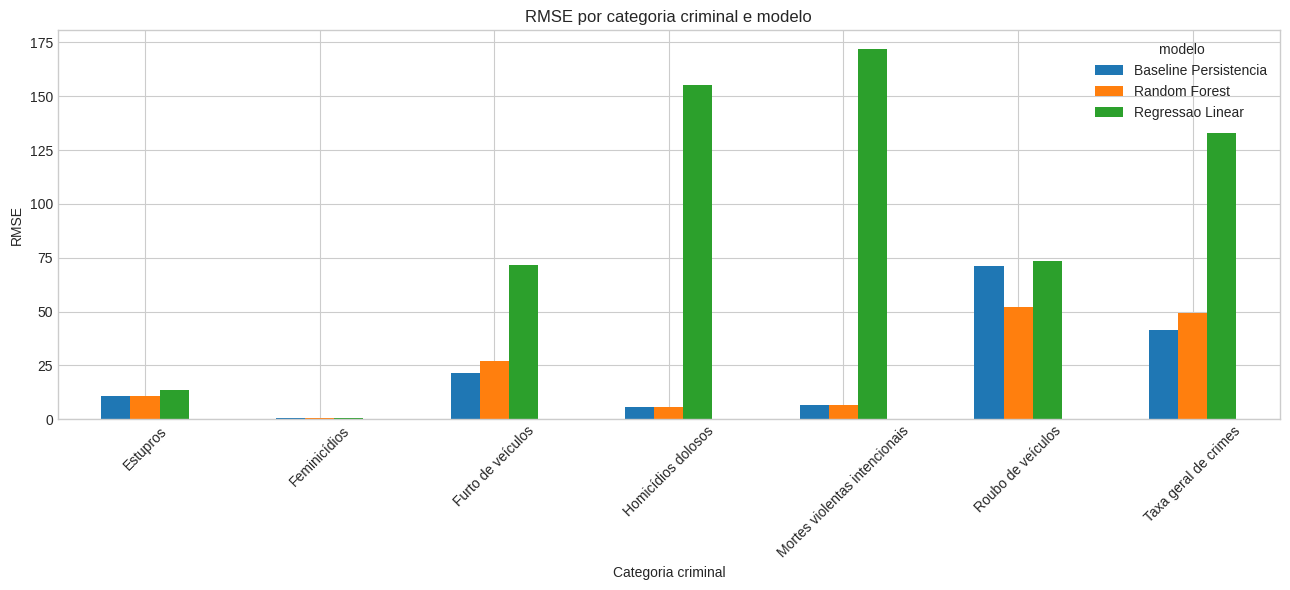

In [16]:
ax = metricas_modelos.pivot(index='target', columns='modelo', values='rmse').plot(
    kind='bar',
    figsize=(13, 6),
    rot=45,
)
ax.set_title('RMSE por categoria criminal e modelo')
ax.set_ylabel('RMSE')
ax.set_xlabel('Categoria criminal')
plt.tight_layout()
plt.show()

## 14. Real vs previsto - melhores modelos

O gráfico abaixo usa apenas o melhor modelo de cada categoria, conforme menor `RMSE`.

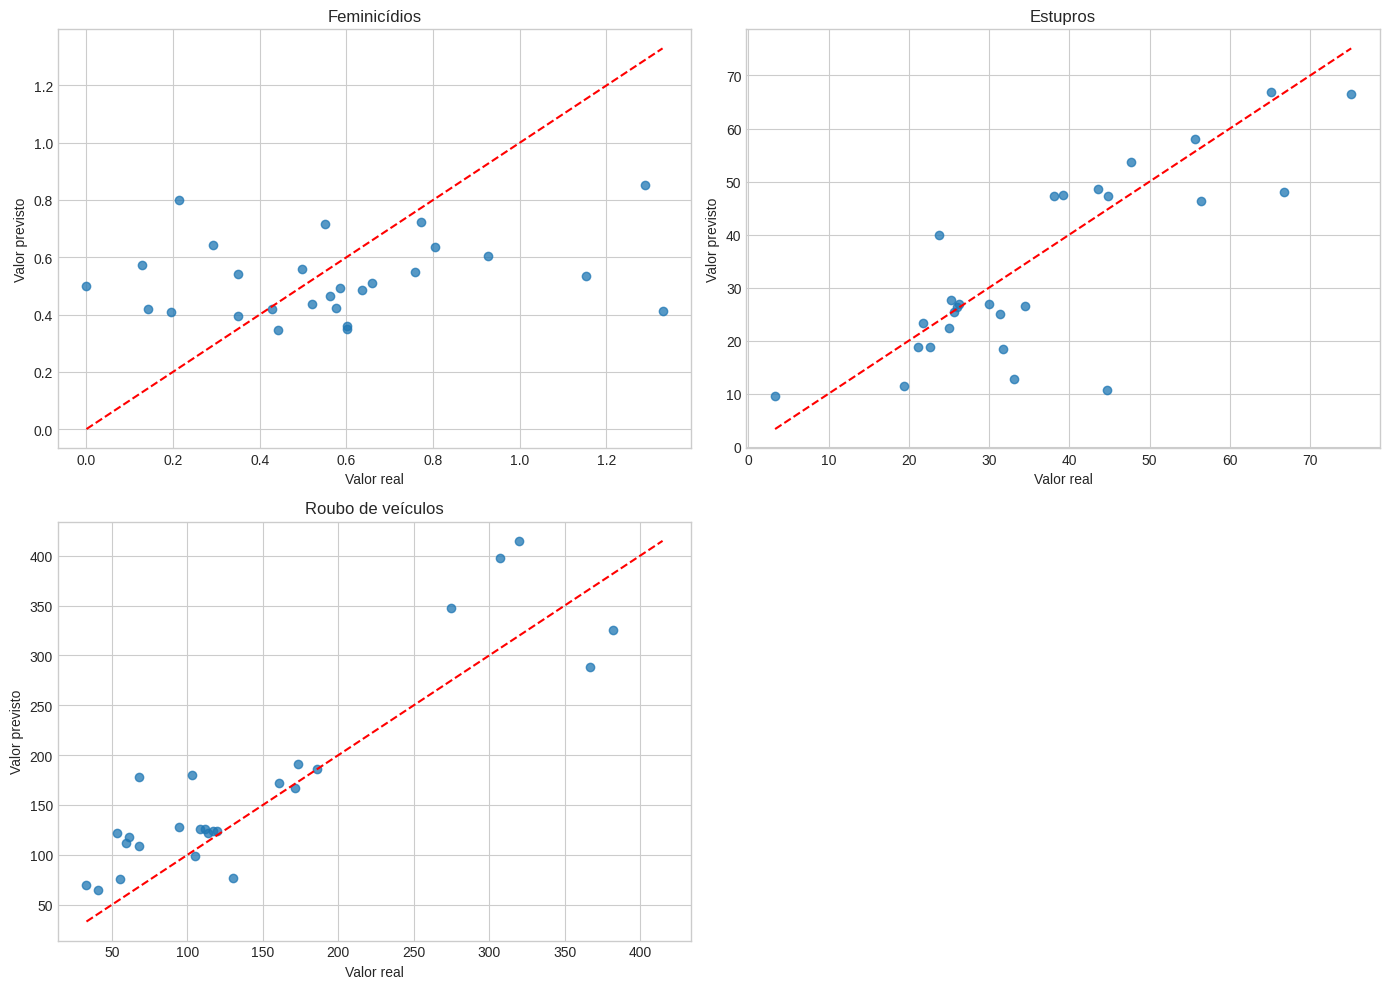

In [17]:
previsoes_melhores = previsoes_modelos.merge(
    melhores_modelos[['target', 'modelo']],
    on=['target', 'modelo'],
    how='inner',
)

targets_plot = list(previsoes_melhores['target'].unique())
qtd_targets = len(targets_plot)
cols = 2
rows = int(np.ceil(qtd_targets / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = np.array(axes).reshape(-1)

for ax, target_nome in zip(axes, targets_plot):
    dados_target = previsoes_melhores[previsoes_melhores['target'] == target_nome]
    limite_min = min(dados_target['valor_real'].min(), dados_target['valor_previsto'].min())
    limite_max = max(dados_target['valor_real'].max(), dados_target['valor_previsto'].max())

    ax.scatter(dados_target['valor_real'], dados_target['valor_previsto'], alpha=0.75)
    ax.plot([limite_min, limite_max], [limite_min, limite_max], color='red', linestyle='--')
    ax.set_title(target_nome)
    ax.set_xlabel('Valor real')
    ax.set_ylabel('Valor previsto')

for ax in axes[qtd_targets:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 15. Análise de resíduos - melhores modelos

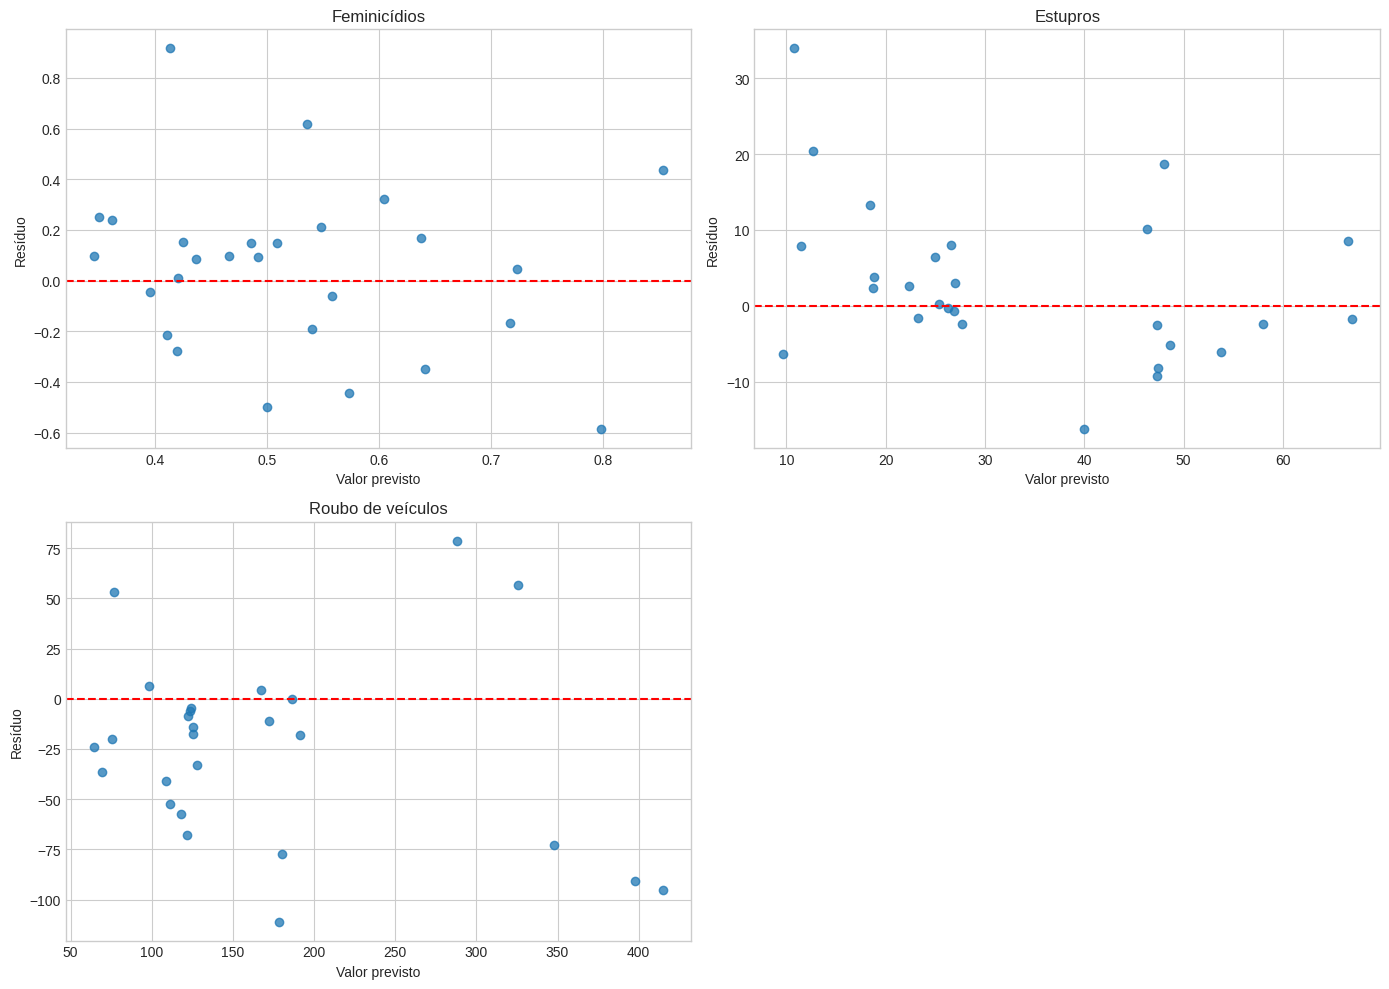

In [18]:
fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = np.array(axes).reshape(-1)

for ax, target_nome in zip(axes, targets_plot):
    dados_target = previsoes_melhores[previsoes_melhores['target'] == target_nome]
    ax.scatter(dados_target['valor_previsto'], dados_target['residuo'], alpha=0.75)
    ax.axhline(0, color='red', linestyle='--')
    ax.set_title(target_nome)
    ax.set_xlabel('Valor previsto')
    ax.set_ylabel('Resíduo')

for ax in axes[qtd_targets:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 16. Maiores erros por categoria

In [19]:
previsoes_melhores.sort_values(
    ['target', 'erro_absoluto'],
    ascending=[True, False],
).groupby('target').head(5)

,ano,codigo_municipio,nome_municipio,sigla_uf,nome_regiao,target,modelo,valor_real,valor_previsto,residuo,erro_absoluto
28,2019,1200401,Rio Branco,AC,Norte,Estupros,Random Forest,44.682423,10.737604,33.944819,33.944819
52,2019,5208707,Goiania,GO,Centro-Oeste,Estupros,Random Forest,33.045030,12.681051,20.363979,20.363979
32,2019,1600303,Macapa,AP,Norte,Estupros,Random Forest,66.755807,48.008674,18.747133,18.747133
31,2019,1501402,Belem,PA,Norte,Estupros,Random Forest,23.714700,39.986660,-16.271960,16.271960
40,2019,2704302,Maceio,AL,Nordeste,Estupros,Random Forest,31.699361,18.441995,13.257366,13.257366
8,2024,2211001,Teresina,PI,Nordeste,Feminicídios,Random Forest,1.329428,0.412982,0.916446,0.916446
23,2024,5002704,Campo Grande,MS,Centro-Oeste,Feminicídios,Random Forest,1.152391,0.535210,0.617181,0.617181
3,2024,1400100,Boa Vista,RR,Norte,Feminicídios,Random Forest,0.212689,0.798690,-0.586001,0.586001
5,2024,1600303,Macapa,AP,Norte,Feminicídios,Random Forest,0.000000,0.499958,-0.499958,0.499958
10,2024,2408102,Natal,RN,Nordeste,Feminicídios,Random Forest,0.127329,0.572951,-0.445622,0.445622


## 17. Importância das variáveis - Random Forest

A tabela mostra as variáveis mais importantes no Random Forest para cada categoria modelada.

In [20]:
importancias_rf = importancias_modelos[
    (importancias_modelos['modelo'] == 'Random Forest')
    & (importancias_modelos['tipo_importancia'] == 'feature_importance')
].copy()

importancias_rf.sort_values(['target', 'valor'], ascending=[True, False]).groupby('target').head(8)

,target,modelo,feature,tipo_importancia,valor
126,Estupros,Random Forest,taxa_estupros_100k_lag1,feature_importance,0.905818
127,Estupros,Random Forest,idhm_educacao,feature_importance,0.026167
128,Estupros,Random Forest,populacao_crescimento_pct,feature_importance,0.018088
129,Estupros,Random Forest,idhm_renda,feature_importance,0.010104
130,Estupros,Random Forest,populacao_total,feature_importance,0.009496
131,Estupros,Random Forest,fluxo_preenchido,feature_importance,0.005763
132,Estupros,Random Forest,idhm_longevidade,feature_importance,0.005741
133,Estupros,Random Forest,ideb_preenchido,feature_importance,0.004438
98,Feminicídios,Random Forest,populacao_total,feature_importance,0.219828
99,Feminicídios,Random Forest,idhm_longevidade,feature_importance,0.180682


## Eixo B — Exploração socioeconômica (sem lag1)

Investigação EXPLORATÓRIA do sinal dos fatores socioeconômicos (IDHM, educação,
população) isolando-os do histórico criminal (`lag1` e `risco_indice_lag1`). Objetivo:
medir quanto esses fatores explicam SOZINHOS, sem prometer poder preditivo. Comparado ao
mesmo baseline de persistência. Sinal fraco é um achado válido.

In [21]:
features_socioeconomicas = [
    f for f in features_base if f not in ('risco_indice_lag1',)
]

eixo_b_metricas = []
for nome_target, coluna_target in targets_criminais.items():
    treino_b, teste_b, estrategia_b = escolher_split_temporal(
        df, features_socioeconomicas + [f'{coluna_target}_lag1'], coluna_target
    )
    if treino_b.empty or teste_b.empty:
        continue

    _, metricas_rf_b, _, importancias_b = treinar_e_avaliar(
        nome_modelo='RF sem lag1 (socioeconomico)',
        nome_target=nome_target,
        estimador=RandomForestRegressor(
            n_estimators=500, max_depth=4, min_samples_leaf=3, random_state=42
        ),
        treino=treino_b,
        teste=teste_b,
        features=features_socioeconomicas,
        target=coluna_target,
        usar_scaler=False,
    )
    metricas_base_b = avaliar_baseline_persistencia(
        nome_target, teste_b, coluna_target, f'{coluna_target}_lag1'
    )
    metricas_rf_b['rmse_baseline'] = metricas_base_b['rmse']
    metricas_rf_b['ganho_rmse_vs_baseline_pct'] = round(
        (metricas_base_b['rmse'] - metricas_rf_b['rmse']) / metricas_base_b['rmse'] * 100, 2
    )
    eixo_b_metricas.append(metricas_rf_b)

eixo_b_metricas = pd.DataFrame(eixo_b_metricas)
print("OK: Eixo B treinado (RF sem lag1)")
display(eixo_b_metricas[['target', 'rmse', 'r2', 'ganho_rmse_vs_baseline_pct']])

OK: Eixo B treinado (RF sem lag1)


,target,rmse,r2,ganho_rmse_vs_baseline_pct
0,Taxa geral de crimes,80.186736,0.259676,-92.59
1,Mortes violentas intencionais,10.568895,0.302071,-65.62
2,Homicídios dolosos,9.016726,0.255626,-62.25
3,Feminicídios,0.330826,-0.020111,13.74
4,Estupros,12.951141,0.372038,-21.85
5,Furto de veículos,85.926298,-0.081707,-299.79
6,Roubo de veículos,96.580573,0.066481,-35.76


In [22]:
colunas_socio = ['idhm', 'idhm_renda', 'idhm_educacao', 'idhm_longevidade',
                 'ideb_preenchido', 'aprendizado_preenchido', 'populacao_crescimento_pct']
colunas_alvo = list(targets_criminais.values())

corr_socio = df[colunas_socio + colunas_alvo].corr().loc[colunas_socio, colunas_alvo]
print("Correlacao (Pearson) fatores socioeconomicos x taxas criminais:")
display(corr_socio.round(3))

assert 'ganho_rmse_vs_baseline_pct' in eixo_b_metricas.columns
assert corr_socio.shape[0] == len(colunas_socio)
print("OK: Eixo B (modelo sem lag1 + correlacoes) concluido")

Correlacao (Pearson) fatores socioeconomicos x taxas criminais:


,taxa_crimes_100k,taxa_mortes_violentas_100k,taxa_homicidios_100k,taxa_feminicidios_100k,taxa_estupros_100k,taxa_furto_veiculos_100k,taxa_roubo_veiculos_100k
idhm,-0.084,-0.586,-0.590,-0.063,-0.109,0.334,-0.062
idhm_renda,-0.011,-0.553,-0.549,-0.071,-0.119,0.367,0.052
idhm_educacao,-0.171,-0.532,-0.536,-0.026,-0.098,0.229,-0.199
idhm_longevidade,-0.003,-0.520,-0.546,-0.104,-0.043,0.348,0.026
ideb_preenchido,0.013,-0.508,-0.458,-0.061,-0.063,0.381,-0.132
aprendizado_preenchido,0.066,-0.592,-0.551,-0.005,0.047,0.411,-0.041
populacao_crescimento_pct,-0.014,-0.024,0.010,0.025,0.420,0.129,-0.246


OK: Eixo B (modelo sem lag1 + correlacoes) concluido


## 18. Conclusões — dois eixos

Os resultados são organizados em dois eixos com objetivos e teses distintas, porque o
dataset é pequeno (~243 linhas), o IDHM é estrutural de 2010 e a educação cobre poucos anos.

### Eixo A — Previsão (inércia temporal)
Para prever a taxa do ano seguinte, o preditor dominante é o histórico do ano anterior
(`lag1`). Toda métrica é reportada como GANHO RELATIVO sobre o baseline de persistência
(`previsão = ano anterior`) e com R² médio ± desvio via validação cruzada temporal — não
um número único. Onde o Random Forest não supera o baseline por margem clara, isso é
declarado: o modelo não agrega valor sobre "ano que vem ≈ ano passado".

Categorias com R² ≤ 0 (ex.: **Feminicídios**) são marcadas como NÃO MODELÁVEIS com os
dados atuais e ficam fora da comparação principal. R²/RMSE de categorias em splits
temporais diferentes NÃO são comparáveis entre si — isso está sinalizado.

### Eixo B — Exploração socioeconômica (sem lag1)
Removendo o `lag1`, mede-se quanto IDHM/educação/população explicam SOZINHOS. O resultado
é EXPLORATÓRIO: a importância de variáveis do Eixo A subestima esses fatores porque o
`lag1` captura a variância primeiro. As correlações e o RF sem lag1 mostram o sinal real —
e, se ele for fraco, isso é um achado honesto, não um fracasso.

### Síntese
Este projeto faz duas coisas válidas e diferentes: (1) previsão por inércia que funciona,
(2) exploração socioeconômica com poder explicativo declarado. Não afirmamos causalidade.
Nenhum algoritmo (incl. boosting) eleva o teto preditivo deste dataset — a limitação é
amostral, não de modelo.

## 19. Exportação dos resultados para PostgreSQL

Os resultados do Machine Learning são salvos no schema `ml` para consumo no Metabase. Essa etapa fecha o ciclo analítico:

`Data Mart -> Notebook ML -> PostgreSQL -> Metabase`

In [ ]:
# Dropar views dependentes ANTES de recriar as tabelas, senao o to_sql (DROP TABLE)
# falha por dependencia. As views sao reconstruidas depois rodando 04-create_ml_datamart.sql.
views_ml = [
    'vw_resumo_metricas_modelos',
    'vw_melhor_modelo_por_categoria',
    'vw_maiores_erros_modelo',
    'vw_importancia_variaveis_rf',
    'vw_splits_modelagem',
    'vw_eixo_b_socioeconomico',
    'vw_correlacao_socioeconomica',
]

with engine.begin() as conn:
    conn.exec_driver_sql('CREATE SCHEMA IF NOT EXISTS ml;')
    for view in views_ml:
        conn.exec_driver_sql(f'DROP VIEW IF EXISTS ml.{view} CASCADE;')

metricas_export = metricas_modelos.copy()
previsoes_export = previsoes_modelos.copy()
importancias_export = importancias_modelos.copy()
splits_export = splits_modelagem.copy()
melhores_export = melhores_modelos.copy()

for df_export in [metricas_export, previsoes_export, importancias_export, splits_export, melhores_export]:
    for coluna in df_export.columns:
        if df_export[coluna].apply(lambda valor: isinstance(valor, list)).any():
            df_export[coluna] = df_export[coluna].apply(lambda valor: ', '.join(map(str, valor)) if isinstance(valor, list) else valor)

metricas_export.to_sql('metricas_modelos', engine, schema='ml', if_exists='replace', index=False)
previsoes_export.to_sql('previsoes_modelos', engine, schema='ml', if_exists='replace', index=False)
importancias_export.to_sql('importancia_variaveis', engine, schema='ml', if_exists='replace', index=False)
splits_export.to_sql('splits_modelagem', engine, schema='ml', if_exists='replace', index=False)
melhores_export.to_sql('melhores_modelos', engine, schema='ml', if_exists='replace', index=False)

# Novas saidas do reposicionamento (Eixo B, CV temporal, correlacoes)
cv_export = cv_metricas.copy()
eixo_b_export = eixo_b_metricas.copy()
corr_export = corr_socio.reset_index().melt(
    id_vars='index', var_name='taxa_alvo', value_name='correlacao'
).rename(columns={'index': 'fator_socioeconomico'})

cv_export.to_sql('cv_temporal', engine, schema='ml', if_exists='replace', index=False)
eixo_b_export.to_sql('eixo_b_socioeconomico', engine, schema='ml', if_exists='replace', index=False)
corr_export.to_sql('correlacao_socioeconomica', engine, schema='ml', if_exists='replace', index=False)

pd.DataFrame({
    'tabela': [
        'ml.metricas_modelos',
        'ml.previsoes_modelos',
        'ml.importancia_variaveis',
        'ml.splits_modelagem',
        'ml.melhores_modelos',
    ],
    'linhas': [
        len(metricas_export),
        len(previsoes_export),
        len(importancias_export),
        len(splits_export),
        len(melhores_export),
    ],
})